# Exploratory Data Analysis

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT/"data"/"raw"/"online_retail_II.xlsx"

In [2]:
df_2010 = pd.read_excel(DATA_PATH, sheet_name = "Year 2009-2010")
df_2011 = pd.read_excel(DATA_PATH, sheet_name = "Year 2010-2011")
df = pd.concat([df_2010, df_2011], ignore_index=True)

In [ ]:
df.duplicated(keep=False).sum()

np.int64(34335)

In [6]:
duplicates = df[df.duplicated(keep=False)]
duplicates.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


# Checking for negative quantities


In [10]:
df_no_duplicates = df.drop_duplicates()
print(df.shape)
print(df_no_duplicates.shape)

(1067371, 8)
(1033036, 8)


In [9]:
negative_quantity = df[df["Quantity"]<0]
negative_quantity.head(20)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [ ]:
# if the value comes out to be True then quantities which are negatives are most likely cancellations
# 2nd output came false 
negative_quantity["Invoice"].str.startswith("C").all(), (df["Invoice"].str.startswith("C") == (df["Quantity"] < 0)).all()

(np.True_, np.False_)

In [ ]:
# only one transaction which is not negative quantity and doesnt start with C in Invoice exists
# this suggests this is a special transaction
df[(df["Invoice"].str.startswith("C")) & (df["Quantity"] >= 0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


# Checking for negative prices

In [19]:
negative_prices = df[df["Price"] < 0]
negative_prices.head(20)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


# Quantity Analysis

In [22]:
df["Quantity"].value_counts()

Quantity
 1        294346
 2        159960
 12       121745
 6         85299
 3         72638
           ...  
-337           1
-1050          1
 698           1
 80995         1
-80995         1
Name: count, Length: 1057, dtype: int64

<Axes: >

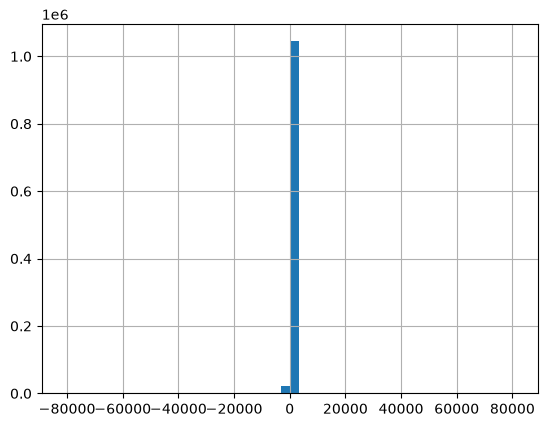

In [23]:
df["Quantity"].hist(bins=50)

<Axes: >

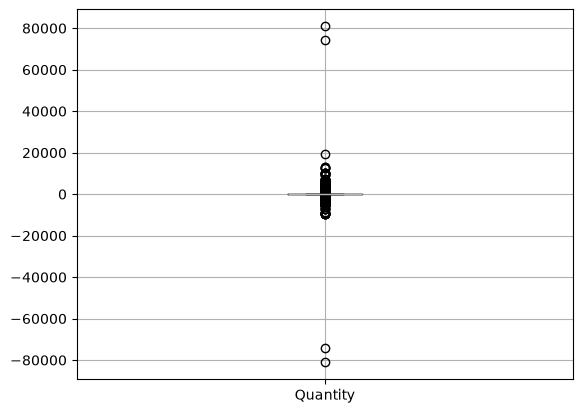

In [24]:
df.boxplot(column="Quantity")

<Axes: >

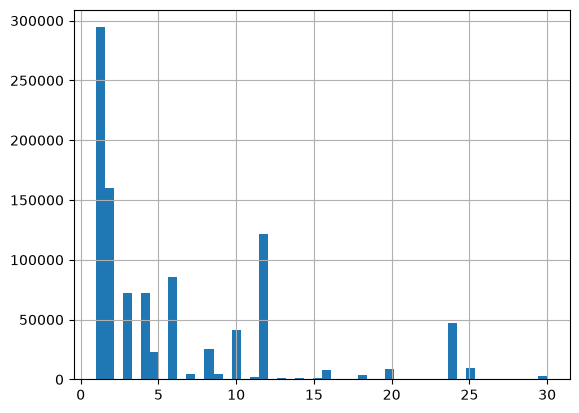

In [29]:
df[df["Quantity"].between(0, 30)]["Quantity"].hist(bins=50)

Most transactions involve small purchase quantities (1, 2, 3, 6, 12, 23 are the most common).
The Quantity distribution is heavily right-skewed, with a small number of extremely large purchases.
There are numerous outliers on both the positive and negative sides.
Negative quantities are primarily associated with cancellation/credit transactions.
A few extremely large positive and negative quantities warrant further investigation during data cleaning before clustering.

In [30]:
df["Price"].value_counts()

Price
1.25       104428
1.65        73808
0.85        69218
2.95        65862
0.42        45438
            ...  
11.25           1
938.59          1
933.17          1
1714.17         1
224.69          1
Name: count, Length: 2807, dtype: int64

<Axes: >

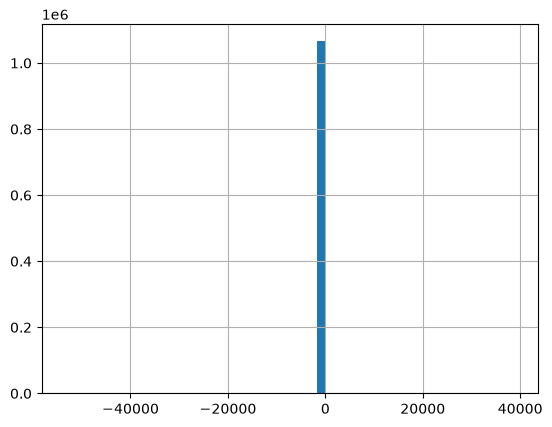

In [31]:
df["Price"].hist(bins=50)

<Axes: >

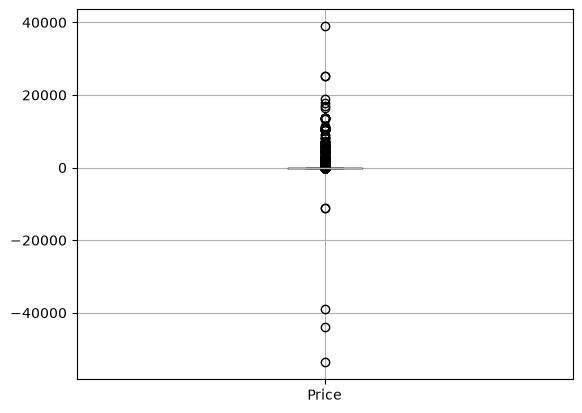

In [33]:
df.boxplot(column="Price")

<Axes: >

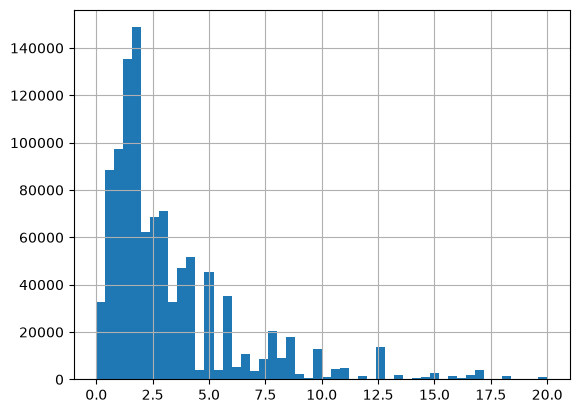

In [36]:
df[df["Price"].between(0,20)]["Price"].hist(bins=50)

most transactions range between 0 and 20 dollars 
negative prices represent bad debt settlements 
there are definitely some high price outliers


In [41]:
df["Country"].value_counts(normalize=True)

Country
United Kingdom          0.919390
EIRE                    0.016738
Germany                 0.016512
France                  0.013426
Netherlands             0.004816
Spain                   0.003570
Switzerland             0.002988
Belgium                 0.002926
Portugal                0.002455
Australia               0.001792
Channel Islands         0.001559
Italy                   0.001437
Norway                  0.001363
Sweden                  0.001278
Cyprus                  0.001102
Finland                 0.000983
Austria                 0.000879
Denmark                 0.000765
Unspecified             0.000708
Greece                  0.000621
Japan                   0.000545
USA                     0.000501
Poland                  0.000501
United Arab Emirates    0.000468
Israel                  0.000348
Hong Kong               0.000341
Singapore               0.000324
Malta                   0.000280
Iceland                 0.000237
Canada                  0.000214
Li

The dataset is heavily dominated by customers from the United Kingdom, accounting for approximately 92% of all transactions.
The second-largest contributor is EIRE, representing only about 1.7% of transactions.
The remaining countries each contribute a relatively small fraction of the dataset.
This indicates a highly imbalanced geographical distribution.

In [44]:
df["Date"] = df["InvoiceDate"].dt.date
df["Date"].value_counts().sort_index()
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Date'],
      dtype='str')

looking for 0 quantity and 0 price rows


In [51]:
zero_quantity= df[df["Price"]==0]
zero_quantity.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Date
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2009-12-01
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,2009-12-01
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,2009-12-01
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,2009-12-01
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,2009-12-01


#checking if date makes sense


In [10]:
df["InvoiceDate"].max()
df["Invoice"]

0          489434
1          489434
2          489434
3          489434
4          489434
            ...  
1067366    581587
1067367    581587
1067368    581587
1067369    581587
1067370    581587
Name: Invoice, Length: 1067371, dtype: object